# UCI HAR Dataset — Autoencoder를 이용한 활동 이상 탐지
가정
- 정상: 누워있는 상황
- 이상: 걷고있는 상황

흐름
- Laying 데이터로 AE 학습 -> 학습된 AE에 Walking 데이터 입력 -> Threshold 초과 시 이상 감지

AE의 이점
- 정상 데이터만을 사용하여 AE를 학습하고 새로운 입력이 학습한 패턴과 다르면 RE가 커져 이상으로 탐지할 수 있다.
- AE는 라벨이 필요없고 입력을 복원하면서 오차를 줄이는 모델로 비지도학습이라는 이점이 있다. 즉, 입력 자체가 정답이 되는 셈이다.

RE란?
- Reconstruction Error: 재구성 오차
- RE = (X - X')²의 평균 (MSE)
- AE가 입력을 복원했을 때 원본과 복원값의 차이로 입력 패턴을 잘 복원하면 RE가 작고 복원을 못하면 RE가 커지게 된다.

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"
TRAIN = "train/"
TEST  = "test/"

INPUT_SIGNAL_TYPES = [
    "body_acc_x_", "body_acc_y_", "body_acc_z_",
    "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
    "total_acc_x_", "total_acc_y_", "total_acc_z_"
]

# UCI HAR 원본 라벨
# 1:WALKING  2:WALKING_UPSTAIRS  3:WALKING_DOWNSTAIRS
# 4:SITTING  5:STANDING          6:LAYING
LABEL_WALKING = 1
LABEL_LAYING  = 6

In [94]:
# X,y 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = []
    for path in X_signals_paths:
        channel = []
        with open(path, 'r') as f:
            for row in f:
                row = row.replace('  ', ' ').strip().split(' ')
                channel.append([np.float32(x) for x in row])
        X_signals.append(channel)
    X_signals = np.array(X_signals)          # (9, samples, 128)
    return np.transpose(X_signals, (1, 2, 0)) # (samples, 128, 9)

def load_y(y_path):
    with open(y_path, 'r') as f:
        return np.array([int(row.strip()) for row in f], dtype=np.int32)

In [95]:
# 원본 데이터 로드
X_train_raw = load_X([DATASET_PATH + TRAIN + "Inertial Signals/" + s + "train.txt" for s in INPUT_SIGNAL_TYPES])
X_test_raw  = load_X([DATASET_PATH + TEST  + "Inertial Signals/" + s + "test.txt"  for s in INPUT_SIGNAL_TYPES])
y_train_raw = load_y(DATASET_PATH + TRAIN + "y_train.txt")
y_test_raw  = load_y(DATASET_PATH + TEST  + "y_test.txt")

print("전체 train shape:", X_train_raw.shape, "labels:", y_train_raw.shape)
print("전체 test  shape:", X_test_raw.shape,  "labels:", y_test_raw.shape)

전체 train shape: (7352, 128, 9) labels: (7352,)
전체 test  shape: (2947, 128, 9) labels: (2947,)


In [96]:
# Laying / Walking 만 필터링
def filter_classes(X, y, keep):
    mask = np.isin(y, keep)
    return X[mask], y[mask]

X_train_f, y_train_f = filter_classes(X_train_raw, y_train_raw, [LABEL_WALKING, LABEL_LAYING])
X_test_f,  y_test_f  = filter_classes(X_test_raw,  y_test_raw,  [LABEL_WALKING, LABEL_LAYING])

print("필터 후 train:", X_train_f.shape)
print("  WALKING:", np.sum(y_train_f == LABEL_WALKING), "  LAYING:", np.sum(y_train_f == LABEL_LAYING))
print("필터 후 test:",  X_test_f.shape)
print("  WALKING:", np.sum(y_test_f  == LABEL_WALKING), "  LAYING:", np.sum(y_test_f  == LABEL_LAYING))

필터 후 train: (2633, 128, 9)
  WALKING: 1226   LAYING: 1407
필터 후 test: (1033, 128, 9)
  WALKING: 496   LAYING: 537


In [97]:
# AE 입력: (samples, 128, 9) → Flatten → (samples, 1152)
def flatten(X):
    return X.reshape(X.shape[0], -1).astype(np.float32)

# 훈련 데이터: Laying 만 남기고 다른 레이블 제거
mask_laying_train = (y_train_f == LABEL_LAYING)
X_train_ae = flatten(X_train_f[mask_laying_train])   # 정상(LAYING)만

# 테스트 데이터: WALKING + LAYING 모두, 레이블 보존
X_test_ae  = flatten(X_test_f)
y_test_ae  = y_test_f.copy()  # 1=WALKING, 6=LAYING

print("AE 훈련 입력 (LAYING only):", X_train_ae.shape)
print("AE 테스트 입력 (WALK+LAY):",  X_test_ae.shape)

AE 훈련 입력 (LAYING only): (1407, 1152)
AE 테스트 입력 (WALK+LAY): (1033, 1152)


In [98]:
# 오토인코더 구성
input_dim    = X_train_ae.shape[1]   # 1152
encoding_dim = 128

inp     = Input(shape=(input_dim,))
encoded = Dense(encoding_dim,        activation='relu')(inp)
encoded = Dense(encoding_dim // 2,   activation='relu')(encoded)
decoded = Dense(encoding_dim // 2,   activation='relu')(encoded)
decoded = Dense(input_dim,           activation='sigmoid')(decoded)

autoencoder = Model(inputs=inp, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1152)           │        74,880 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,880 (917.50 KB)

 Trainable params: 234,880 (917.50 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
# 모델 학습 (LAYING 정상 데이터만)
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.1
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - loss: 0.2180 - val_loss: 0.1722
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1797 - val_loss: 0.1024
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1105 - val_loss: 0.0353
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0582 - val_loss: 0.0090
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0365 - val_loss: 0.0070
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0295 - val_loss: 0.0065
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0256 - val_loss: 0.0040
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0216 - val_loss: 0.0034
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0171 - val_loss: 0.0029
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0137 - val_loss: 0.0026
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0121 - val_loss: 0.0029
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0117 - val_loss: 0.0029


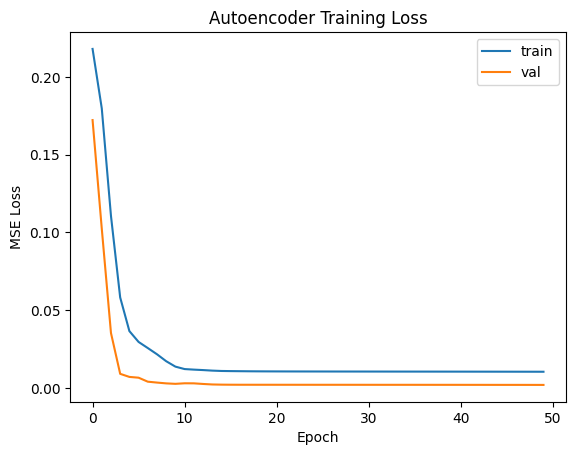

In [100]:
# 학습 곡선
plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [101]:
# Reconstruction Error 계산
preds = autoencoder.predict(X_test_ae)
mse   = np.mean(np.power(X_test_ae - preds, 2), axis=1)

# true_class: 0 = LAYING(정상), 1 = WALKING(이상)
true_class = np.where(y_test_ae == LABEL_LAYING, 0, 1)

error_df = pd.DataFrame({
    'reconstruction_error': mse,
    'true_class': true_class,
    'label': np.where(true_class == 0, 'LAYING', 'WALKING')
})
error_df.describe()

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


,reconstruction_error,true_class
count,1033.000000,1033.000000
mean,0.110491,0.480155
std,0.108688,0.499848
min,0.000080,0.000000
25%,0.002663,0.000000
50%,0.115220,0.000000
75%,0.198071,1.000000
max,0.432867,1.000000


In [102]:
# RE 분포 비교 (LAYING vs WALKING)
for label, grp in error_df.groupby('label'):
    print(f"{label:8s}  mean RE = {grp.reconstruction_error.mean():.4f}  "
          f"max RE = {grp.reconstruction_error.max():.4f}")

LAYING    mean RE = 0.0134  max RE = 0.1751
WALKING   mean RE = 0.2156  max RE = 0.4329


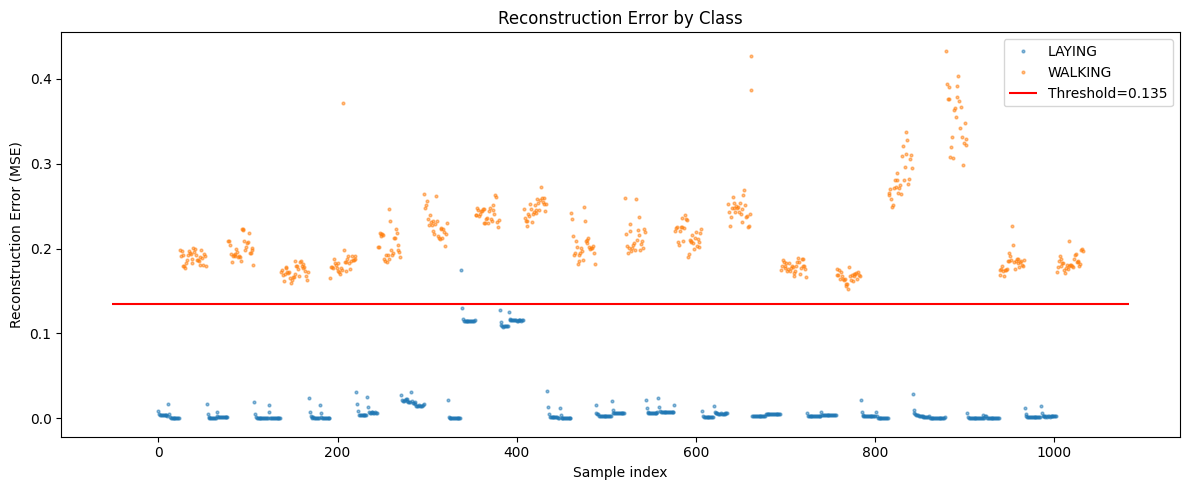

In [103]:
# 산점도: 클래스별 RE
# 그래프를 보고 threshold 값을 조정
THRESHOLD = 0.135

fig, ax = plt.subplots(figsize=(12, 5))
for label, grp in error_df.groupby('label'):
    ax.plot(grp.index, grp.reconstruction_error,
            marker='o', ms=2, linestyle='', alpha=0.5, label=label)
ax.hlines(THRESHOLD, ax.get_xlim()[0], ax.get_xlim()[1],
          colors='red', linewidth=1.5, label=f'Threshold={THRESHOLD:.3f}')
ax.legend()
ax.set_title('Reconstruction Error by Class')
ax.set_xlabel('Sample index')
ax.set_ylabel('Reconstruction Error (MSE)')
plt.tight_layout()
plt.show()

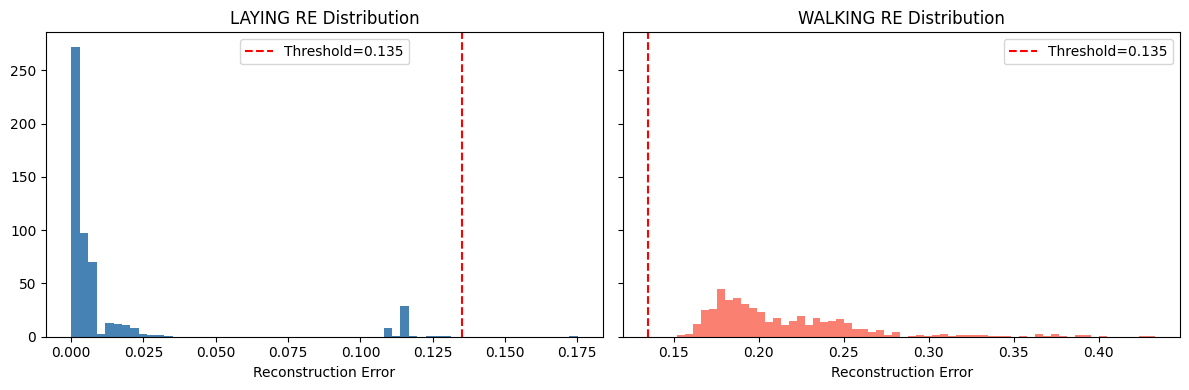

In [104]:
# Histogram 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (label, grp) in zip(axes, error_df.groupby('label')):
    ax.hist(grp.reconstruction_error, bins=60, color='steelblue' if label=='LAYING' else 'salmon')
    ax.axvline(THRESHOLD, color='red', linestyle='--', label=f'Threshold={THRESHOLD:.3f}')
    ax.set_title(f'{label} RE Distribution')
    ax.set_xlabel('Reconstruction Error')
    ax.legend()
plt.tight_layout()
plt.show()

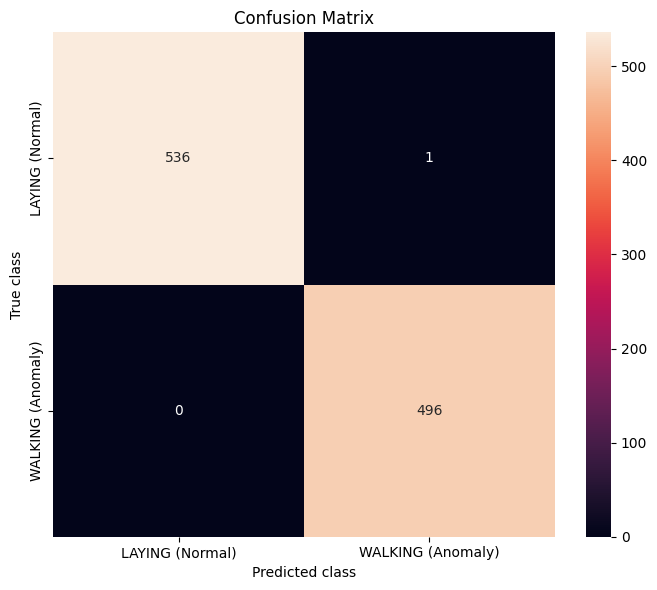

                   precision    recall  f1-score   support

  LAYING (Normal)       1.00      1.00      1.00       537
WALKING (Anomaly)       1.00      1.00      1.00       496

         accuracy                           1.00      1033
        macro avg       1.00      1.00      1.00      1033
     weighted avg       1.00      1.00      1.00      1033



In [105]:
# Threshold 적용 → 예측
# 0=LAYING(정상), 1=WALKING(이상)
y_pred = (error_df.reconstruction_error > THRESHOLD).astype(int)

# 혼동 행렬
LABELS_DISPLAY = ['LAYING (Normal)', 'WALKING (Anomaly)']
cm = confusion_matrix(error_df.true_class, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=LABELS_DISPLAY, yticklabels=LABELS_DISPLAY)
plt.title('Confusion Matrix')
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.tight_layout()
plt.show()

print(classification_report(error_df.true_class, y_pred,
                             target_names=LABELS_DISPLAY))